# RMSE bar charts by company and regime

Data source: the three company summary tables in `ALL_TABLES.ipynb` (SPY, AAPL, MSFT) — regimes × models × rolling methods (none / monthly / daily).

Twelve charts: SPY (4 regimes), then AAPL (4), then MSFT (4). Each chart: models on the x-axis; three colored bars per model for the rolling methods.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path(".").resolve()
ALL_TABLES = HERE / "ALL_TABLES.ipynb"

COMPANIES = ["SPY", "AAPL", "MSFT"]
REGIMES = ["2008-2009", "2013-2014", "2018-2019", "2019-2020"]
MODELS = ["GBM", "Merton", "Heston–Merton", "GARCH–Merton"]
ROLLINGS = ["none", "monthly", "daily"]
COLORS = {"none": "#4C72B0", "monthly": "#55A868", "daily": "#C44E52"}


def parse_company_tables(nb_path: Path) -> dict[str, list[dict]]:
    """Read only the three big company tables from ALL_TABLES.ipynb."""
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    out: dict[str, list[dict]] = {}
    for cell in nb["cells"]:
        if cell.get("cell_type") != "markdown":
            continue
        src = "".join(cell.get("source", []))
        m = re.match(
            r"###\s+(SPY|AAPL|MSFT)\s+[—\-]\s+RMSE index",
            src.strip(),
        )
        if not m:
            continue
        company = m.group(1)
        rows = []
        for line in src.splitlines():
            line = line.strip()
            if not line.startswith("|") or line.startswith("|---") or "Regime" in line:
                continue
            parts = [p.strip() for p in line.strip("|").split("|")]
            if len(parts) < 5:
                continue
            regime, model, none_v, monthly_v, daily_v = parts[:5]
            if regime not in REGIMES or model not in MODELS:
                continue
            rows.append(
                {
                    "regime": regime,
                    "model": model,
                    "none": float(none_v),
                    "monthly": float(monthly_v),
                    "daily": float(daily_v),
                }
            )
        out[company] = rows
    missing = [c for c in COMPANIES if c not in out]
    if missing:
        raise RuntimeError(f"Missing company tables in ALL_TABLES.ipynb: {missing}")
    return out


DATA = parse_company_tables(ALL_TABLES)
for c in COMPANIES:
    print(f"{c}: {len(DATA[c])} rows")

SPY: 16 rows
AAPL: 16 rows
MSFT: 16 rows


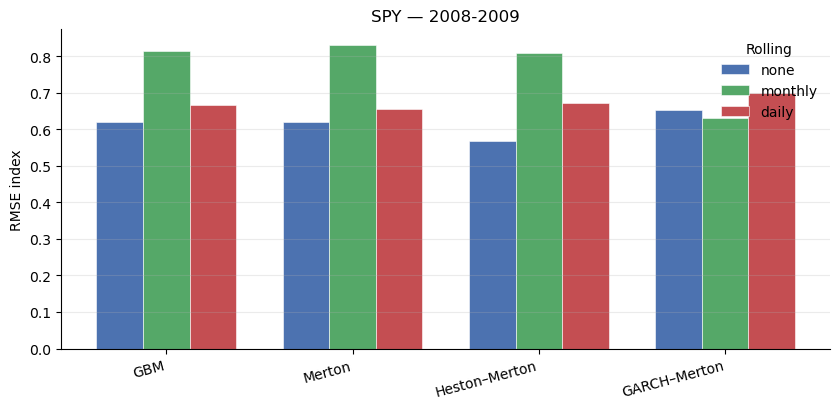

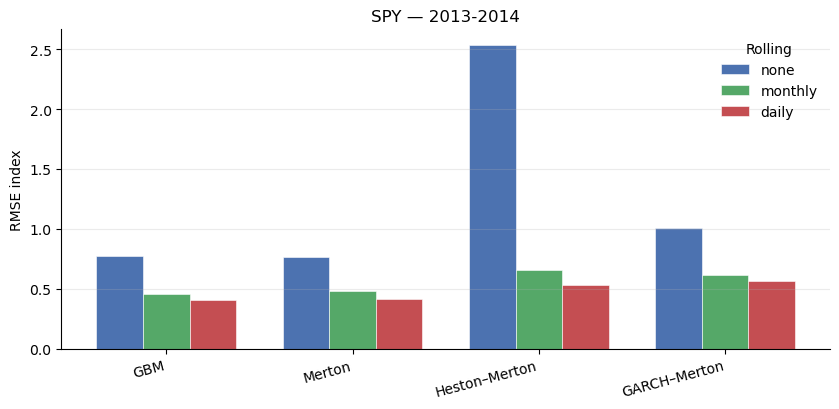

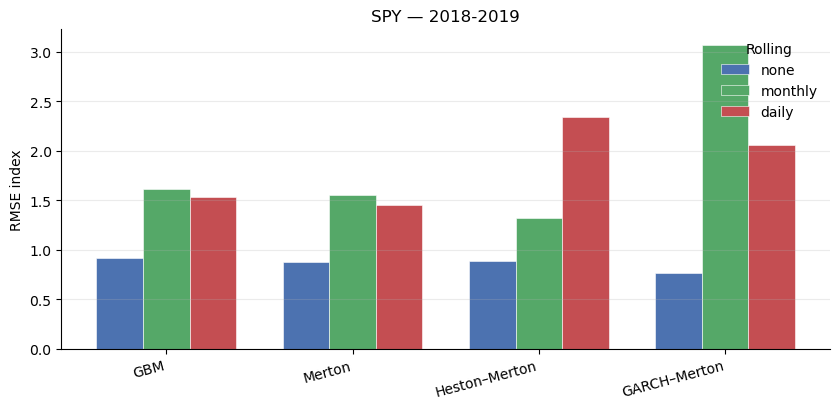

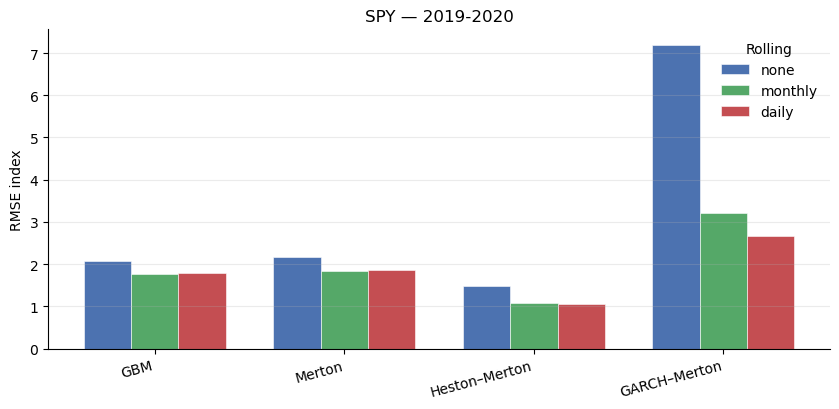

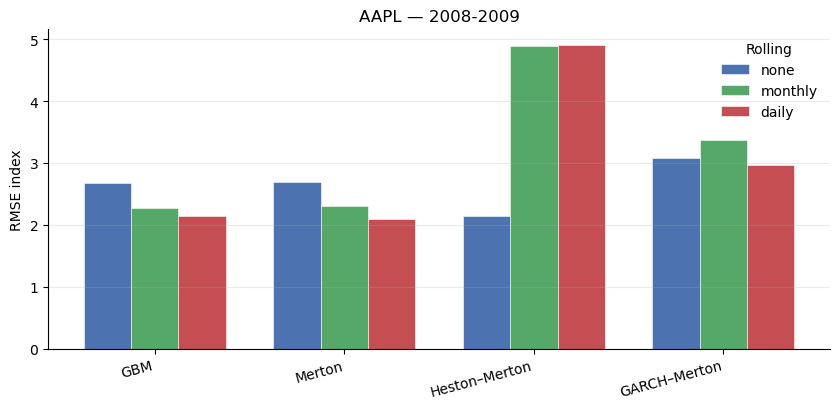

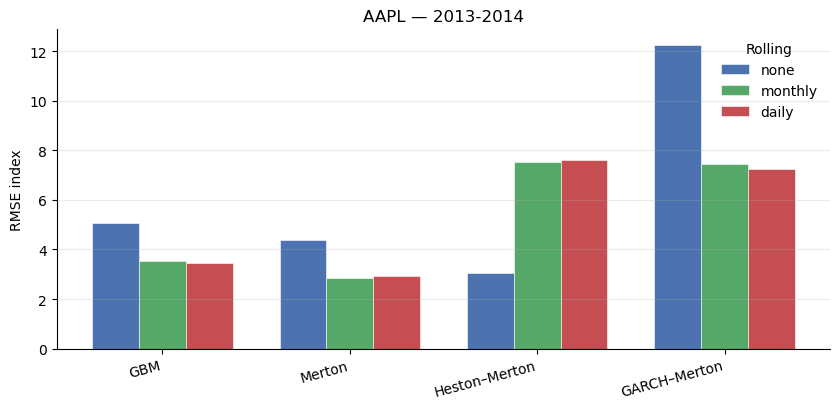

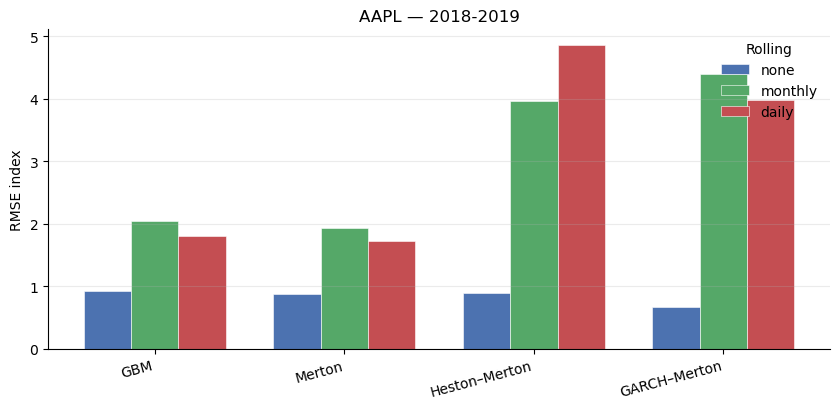

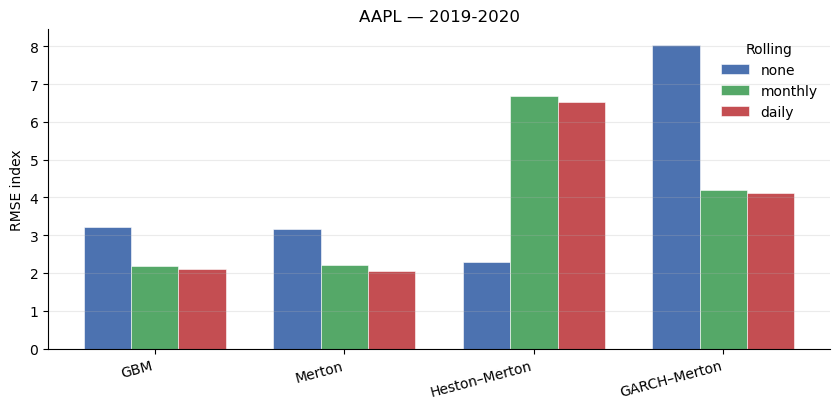

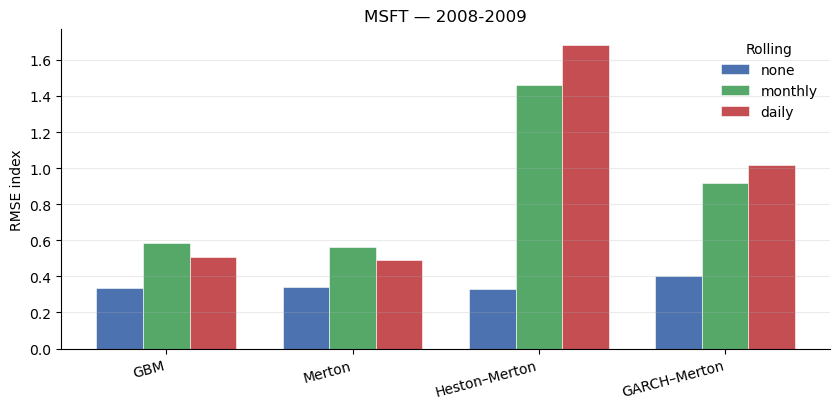

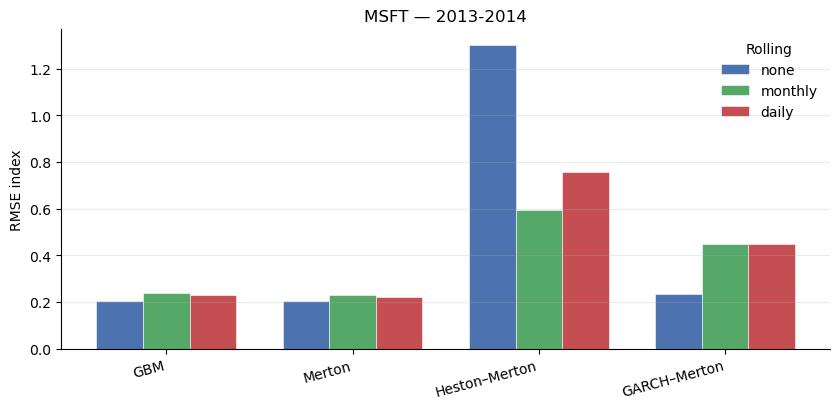

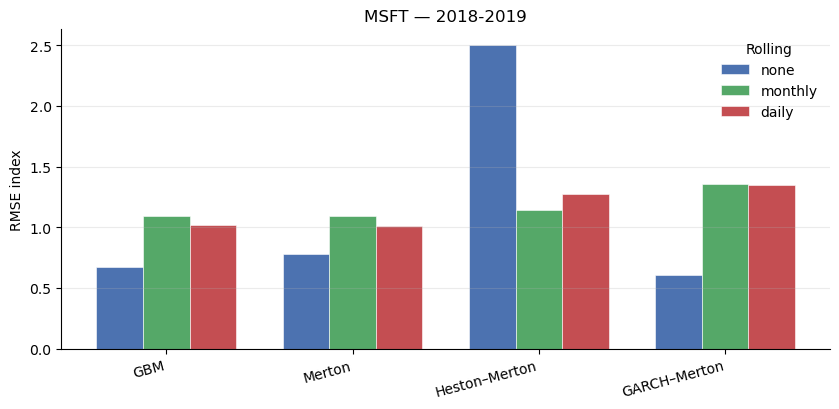

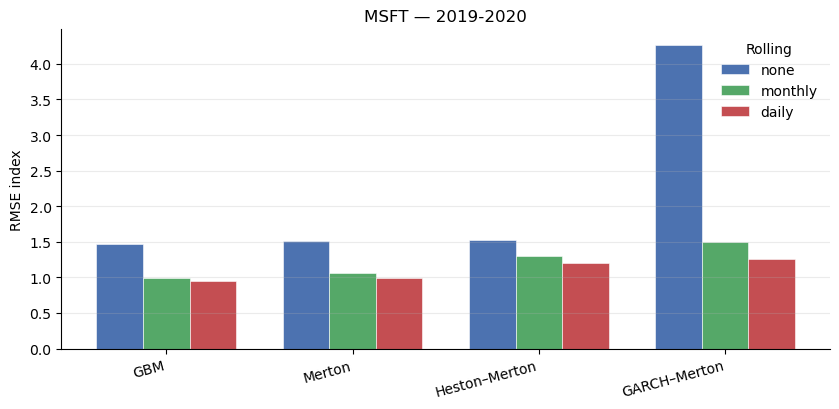

Plotted 12 charts.


In [2]:
def rows_for(company: str, regime: str) -> list[dict]:
    by_model = {r["model"]: r for r in DATA[company] if r["regime"] == regime}
    missing = [m for m in MODELS if m not in by_model]
    if missing:
        raise RuntimeError(f"{company} {regime}: missing models {missing}")
    return [by_model[m] for m in MODELS]


def plot_regime_bars(company: str, regime: str, ax):
    rows = rows_for(company, regime)
    x = np.arange(len(MODELS))
    width = 0.25
    for i, rolling in enumerate(ROLLINGS):
        vals = [r[rolling] for r in rows]
        ax.bar(
            x + (i - 1) * width,
            vals,
            width,
            label=rolling,
            color=COLORS[rolling],
            edgecolor="white",
            linewidth=0.4,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, rotation=15, ha="right")
    ax.set_ylabel("RMSE index")
    ax.set_title(f"{company} — {regime}")
    ax.legend(title="Rolling", frameon=False, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)


fig_list = []
for company in COMPANIES:
    for regime in REGIMES:
        fig, ax = plt.subplots(figsize=(8.5, 4.2))
        plot_regime_bars(company, regime, ax)
        fig.tight_layout()
        fig_list.append(fig)
        display(fig)
        plt.close(fig)

print(f"Plotted {len(fig_list)} charts.")

In [3]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = HERE / "RMSE_BAR_CHARTS.pdf"

with PdfPages(pdf_path) as pdf:
    for company in COMPANIES:
        for regime in REGIMES:
            fig, ax = plt.subplots(figsize=(8.5, 4.2))
            plot_regime_bars(company, regime, ax)
            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

print(f"Wrote {pdf_path}")

Wrote /Users/sophia/Desktop/Study📄/202606 - Pioneer/Research/Coding tests/Results_In_Short/RMSE_BAR_CHARTS.pdf
